# **Primer Parcial - Inteligencia Artificial**

**Apellidos y Nombre:** Vasquez Caiza Juan Marcelo.

**Carrera:** Ingenieria de Sistemas. 

In [63]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# **CARGAMOS LOS DATOS**

Haremos uso del dataset Argentina_weather_data, que contiene las observaciones meteorologicas diarias de Argentina a lo largo de 2 decadas. Cada fila representa un registro meteorologico diario unico.

Country: Nombre del país

Date: Fecha de observación (DD-MM-AAAA)

Temp_Max: Temperatura máxima (°C)

Temp_Min: Temperatura mínima (°C)

Temp_Mean: Temperatura media (°C)

Precipitation_Sum: Precipitación diaria total (mm)

Windspeed_Max: Velocidad máxima del viento (km/h)

Windgusts_Max: Ráfagas de viento máximas (km/h)

Sunshine_Duration: Duración total de la luz solar (segundos)

In [64]:
data = pd.read_csv('C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Parcial1/Argentina_weather_data.csv')
data

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration
0,Argentina,01-01-2000,33.9,20.7,27.5,0.0,17.9,32.8,49047.75
1,Argentina,02-01-2000,32.9,22.2,27.3,0.6,23.1,43.6,48969.22
2,Argentina,03-01-2000,32.1,21.0,26.9,0.0,20.6,40.7,48921.57
3,Argentina,04-01-2000,32.2,20.9,26.7,0.0,25.1,47.2,48091.20
4,Argentina,05-01-2000,30.5,21.0,25.7,0.0,23.7,45.4,48922.09
...,...,...,...,...,...,...,...,...,...
8761,Argentina,27-12-2023,32.0,15.8,23.7,0.6,27.0,51.8,40577.93
8762,Argentina,28-12-2023,31.3,18.9,25.0,0.0,22.7,45.0,48722.72
8763,Argentina,29-12-2023,25.1,15.3,20.0,0.0,25.9,47.2,49242.36
8764,Argentina,30-12-2023,30.3,13.9,22.4,0.0,19.8,37.8,49097.88


In [65]:
num_filas, num_columnas = data.shape

print("Número de filas:", num_filas)
print("Número de columnas:", num_columnas)

Número de filas: 8766
Número de columnas: 9


# **PREPROCESAMIENTO DE DATOS**

Verificamos, la informacion de los tipos de datos y si estos presentan valores vacios o nulos.

In [66]:
print('INFORMACION DE TIPO DE DATOS')
data.info()
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            8766 non-null   object 
 1   Date               8766 non-null   object 
 2   Temp_Max           8766 non-null   float64
 3   Temp_Min           8766 non-null   float64
 4   Temp_Mean          8766 non-null   float64
 5   Precipitation_Sum  8766 non-null   float64
 6   Windspeed_Max      8766 non-null   float64
 7   Windgusts_Max      8766 non-null   float64
 8   Sunshine_Duration  8766 non-null   float64
dtypes: float64(7), object(2)
memory usage: 616.5+ KB

DATOS VACIOS
Country              0
Date                 0
Temp_Max             0
Temp_Min             0
Temp_Mean            0
Precipitation_Sum    0
Windspeed_Max        0
Windgusts_Max        0
Sunshine_Duration    0
dtype: int64


Se pudo observar anteriormente que la fecha es un dato de tipo objeto asi que lo convertimos en un dato de tipo fecha, para que pandas pueda manejar las fechas correctamente.Tambien la columna Date es establecida como el indice del DataFrame, lo que facilita el acceso, la manipulacion y la visualizacion de los datos cronologicamente.   

In [67]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data.set_index('Date', inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8766 entries, 2000-01-01 to 2023-12-31
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            8766 non-null   object 
 1   Temp_Max           8766 non-null   float64
 2   Temp_Min           8766 non-null   float64
 3   Temp_Mean          8766 non-null   float64
 4   Precipitation_Sum  8766 non-null   float64
 5   Windspeed_Max      8766 non-null   float64
 6   Windgusts_Max      8766 non-null   float64
 7   Sunshine_Duration  8766 non-null   float64
dtypes: float64(7), object(1)
memory usage: 616.4+ KB


# **Normalizacion multivariada**
Creamos una lista que contiene los nombres de las columnas que serviran como caracteristicas de entrada para el modelo. (input_features)

Y otra lista que contiene a la  variable objetivo, la columna que el modelo que intentara predecir. (output_feature)

In [ ]:
input_features = ['Temp_Mean', 'Precipitation_Sum', 'Windspeed_Max', 'Sunshine_Duration']
output_feature = 'Temp_Mean'

Normalizamos las caracteristicas de entrada y la variable objetivo.

In [ ]:
input_scaler = MinMaxScaler(feature_range=(0, 1))
input_scaled = input_scaler.fit_transform(data[input_features])


output_scaler = MinMaxScaler(feature_range=(0, 1))
output_scaled = output_scaler.fit_transform(data[[output_feature]])

# **Creacion de secuencias**
Definimos la ventana de tiempo (look_back = 60) es decir el tiempo que usara el modelo (60 dias anteriores).
Se inicializan 2 listas vacias que guardaran los valores de entrada y de salida correspondiente a cada secuencia.


In [70]:
look_back = 60
X = []
Y = []
for i in range(look_back, len(input_scaled)):
    X.append(input_scaled[i-look_back:i, :])
    Y.append(output_scaled[i, 0])

X, Y = np.array(X), np.array(Y)

In [71]:
print(f'Forma final de los datos X: {X.shape}')
print(f'Forma final de los datos Y: {Y.shape}')

Forma final de los datos X: (8706, 60, 4)
Forma final de los datos Y: (8706,)


# **DIVISION DE DATOS**

In [72]:
X_tensor = torch.from_numpy(X).float()
Y_tensor = torch.from_numpy(Y).float()

train_size = int(len(X_tensor) * 0.8)

X_train = X_tensor[:train_size]
Y_train = Y_tensor[:train_size]
X_test = X_tensor[train_size:]
Y_test = Y_tensor[train_size:]

In [73]:
print(X_train.shape[0])
print(X_test.shape[0])

6964
1742


# **DEFINICION DEL MODELO**

In [74]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size):
        super(LSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

In [75]:
input_size = len(input_features)
hidden_layer_size = 100
num_layers = 2
output_size = 1
model = LSTM(input_size, hidden_layer_size, num_layers, output_size)

# **ENTRENAMIENTO**

In [76]:
def fit_regression(model, X_train, Y_train, X_test, Y_test, epochs=60, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"Comenzando entrenamiento en {device}...")
    
    for epoch in range(1, epochs + 1):
        model.train()
        x_train_batch = X_train.to(device)
        y_train_batch = Y_train.to(device)
        predictions = model(x_train_batch)
        loss = criterion(predictions, y_train_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f"Época [{epoch}/{epochs}], Pérdida de Entrenamiento: {loss.item():.5f}")

    print("Entrenamiento finalizado.")

    model.eval()
    with torch.no_grad():
        x_test_batch = X_test.to(device)
        y_test_batch = Y_test.to(device)
        
        predictions_test = model(x_test_batch)
        test_loss = criterion(predictions_test, y_test_batch)
        
        r2 = r2_score(y_test_batch.cpu().numpy(), predictions_test.cpu().numpy())
        print(f"\nPérdida de Prueba (MSE): {test_loss.item():.5f}")
        print(f"R² Score en datos de Prueba: {r2:.5f}")

In [77]:
fit_regression(model, X_train, Y_train, X_test, Y_test, epochs=100)

Comenzando entrenamiento en cuda...


c:\Users\asus\anaconda3\envs\IAPacheco\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([6964])) that is different to the input size (torch.Size([6964, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Época [10/100], Pérdida de Entrenamiento: 0.04529
Época [20/100], Pérdida de Entrenamiento: 0.03591
Época [30/100], Pérdida de Entrenamiento: 0.03247
Época [40/100], Pérdida de Entrenamiento: 0.03221
Época [50/100], Pérdida de Entrenamiento: 0.03224
Época [60/100], Pérdida de Entrenamiento: 0.03222
Época [70/100], Pérdida de Entrenamiento: 0.03220
Época [80/100], Pérdida de Entrenamiento: 0.03218
Época [90/100], Pérdida de Entrenamiento: 0.03217
Época [100/100], Pérdida de Entrenamiento: 0.03216
Entrenamiento finalizado.

Pérdida de Prueba (MSE): 0.03260
R² Score en datos de Prueba: 0.02693


c:\Users\asus\anaconda3\envs\IAPacheco\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1742])) that is different to the input size (torch.Size([1742, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# **PREDICCION DE 30 DIAS**

Ponemos el modelo en modo Evaluacion.

In [78]:
model.eval()

LSTM(
  (lstm): LSTM(4, 100, num_layers=2, batch_first=True)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [79]:
last_60_days = X_train[-1].unsqueeze(0).to('cuda')
future_predictions = []

Añadimos un bucle para predecir os 30 dias.

In [ ]:
for _ in range(30):
    with torch.no_grad():
        
        predicted_value = model(last_60_days)
        
        
        future_predictions.append(predicted_value.item())

        
        new_input_features = last_60_days.clone()
        new_input_features[0, -1, 0] = predicted_value.item()

        
        last_60_days = torch.cat((new_input_features[:, 1:, :], new_input_features[:, -1:, :]), dim=1)



In [81]:
# Desnormalizar las predicciones a la escala original
# Las predicciones son solo la temperatura, así que necesitamos una forma específica
future_predictions_scaled = np.array(future_predictions).reshape(-1, 1)
future_predictions_original = output_scaler.inverse_transform(future_predictions_scaled)

In [82]:
print(f'\nPredicciones para los próximos 30 días (en °C):')
print(future_predictions_original.flatten())


Predicciones para los próximos 30 días (en °C):
[15.99879141 15.98033349 15.96413781 15.95513027 15.95119479 15.95015638
 15.95050325 15.95135295 15.9522572  15.95303164 15.9536272  15.9540526
 15.95434056 15.95453035 15.95464925 15.95472233 15.95476596 15.95479214
 15.95480523 15.95481395 15.95481722 15.95481831 15.95481941 15.95481941
 15.95481941 15.95481831 15.95481831 15.95481831 15.95481831 15.95481831]


# **VISUALIZACION DE RESULTADOS**

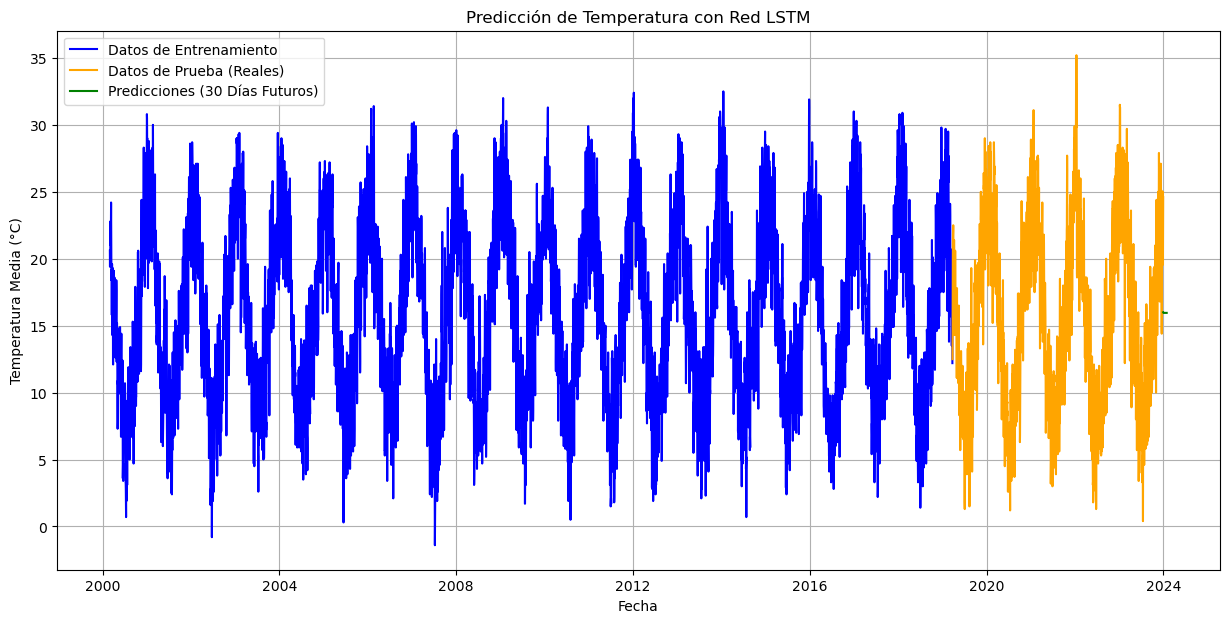

In [83]:
import matplotlib.pyplot as plt

Y_train_original = output_scaler.inverse_transform(Y_train.cpu().numpy().reshape(-1, 1)).flatten()
# Datos de prueba
Y_test_original = output_scaler.inverse_transform(Y_test.cpu().numpy().reshape(-1, 1)).flatten()

# Crear un eje x para los datos
train_dates = data.index[look_back:look_back + len(Y_train_original)]
test_dates = data.index[look_back + len(Y_train_original):look_back + len(Y_train_original) + len(Y_test_original)]
future_dates = pd.date_range(start=test_dates[-1], periods=30, freq='D')

plt.figure(figsize=(15, 7))
plt.plot(train_dates, Y_train_original, label='Datos de Entrenamiento', color='blue')
plt.plot(test_dates, Y_test_original, label='Datos de Prueba (Reales)', color='orange')
plt.plot(future_dates, future_predictions_original, label='Predicciones (30 Días Futuros)', color='green')

plt.title('Predicción de Temperatura con Red LSTM')
plt.xlabel('Fecha')
plt.ylabel('Temperatura Media (°C)')
plt.legend()
plt.grid(True)
plt.show()